1. Primera prueba para entrenar a los modelos

En este caso vamos a seleccionar el dataset UNSW-NB15 para entrenar un modelo RF y ver cómo se comporta. Cogeremos los datos de TRAIN y haremos un K-FOLD para entrenar al modelo. Después, miraremos la inferencia con el dataset de TEST.

In [1]:
import os
import time
import joblib
import numpy as np
import polars as pl
import psutil

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# OPTUNA

import optuna


In [3]:
# 1. Carga de los archivos
path_train = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv"
path_test  = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv"

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)

TARGET_COL = "attack_cat"

# 2. Crear y_train e y_test 
y_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8) # Ahorro de memoria para tu TFG
)

y_test = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

# 3. Crear x_train e x_test
# En Polars es simplemente .drop()
x_train = df_train.drop(TARGET_COL)
x_test  = df_test.drop(TARGET_COL)

# 4. Verificación rápida
print(f"Forma de x_train: {x_train.shape} | Clases únicas en y_train: {y_train.unique().to_list()}")
print("\nDistribución de clases en Train:")
print(y_train.value_counts())

print("\nDistribución de clases en Test:")
print(y_test.value_counts())

Forma de x_train: (175341, 12) | Clases únicas en y_train: [-1, 1]

Distribución de clases en Train:
shape: (2, 2)
┌───────┬────────┐
│ label ┆ count  │
│ ---   ┆ ---    │
│ i8    ┆ u32    │
╞═══════╪════════╡
│ 1     ┆ 56000  │
│ -1    ┆ 119341 │
└───────┴────────┘

Distribución de clases en Test:
shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 1     ┆ 37000 │
│ -1    ┆ 45332 │
└───────┴───────┘


In [4]:
# 1. Convertimos el bloque de TRAIN a NumPy
X_full_train = x_train.to_numpy()
y_full_train = y_train.to_numpy()

# 2. DIVIDIMOS: Sacamos un 20% para VALIDACIÓN
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_full_train, y_full_train, test_size=0.2, random_state=42, stratify=y_full_train
)

# 3. El TEST lo dejamos aparte (NumPy)
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

print(f"Entrenamiento: {X_train_np.shape[0]} muestras")
print(f"Validación:    {X_val_np.shape[0]} muestras")
print(f"Test:          {X_test_np.shape[0]} muestras")

Entrenamiento: 140272 muestras
Validación:    35069 muestras
Test:          82332 muestras


In [10]:
# ==========================================
# 1. ENTRENAMIENTO Y VALIDACIÓN
# ==========================================
print("--- Iniciando Fase de Entrenamiento ---")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=14,
    class_weight="balanced_subsample",
    n_jobs=-1, 
    random_state=42
)

# Medimos entrenamiento
t_start_train = time.perf_counter()
rf.fit(X_train_np, y_train_np)
t_end_train = time.perf_counter()

print(f"✅ Modelo entrenado en: {t_end_train - t_start_train:.4f} s")

# Evaluación en el set de VALIDACIÓN (para ajuste interno)
y_val_pred = rf.predict(X_val_np)
print("\n[Métricas en Conjunto de VALIDACIÓN]")
print(classification_report(y_val_np, y_val_pred, digits=4))

# ==========================================
# 2. EVALUACIÓN FINAL Y MONITORIZACIÓN (TEST)
# ==========================================

def monitor_test_performance(model, X_test, y_test):
    # Obtener el proceso para medir recursos
    process = psutil.Process(os.getpid())
    
    # Calentamiento (opcional, para estabilizar CPU)
    _ = model.predict(X_test[:500])
    
    # Estado inicial
    process.cpu_percent(interval=None) # Reset del contador de CPU
    ram_inicial = process.memory_info().rss / (1024 * 1024)
    
    # --- INFERENCIA ---
    t_start = time.perf_counter()
    y_test_pred = model.predict(X_test)
    t_end = time.perf_counter()
    # ------------------
    
    # Estado final
    cpu_final = process.cpu_percent(interval=None)
    ram_final = process.memory_info().rss / (1024 * 1024)
    
    # Cálculos
    tiempo_total = t_end - t_start
    aciertos = (y_test_pred == y_test).sum()
    total = len(y_test)
    latencia_ms = (tiempo_total / total) * 1000
    
    print("\n" + "="*45)
    print("      EVALUACIÓN FINAL SOBRE TEST")
    print("="*45)
    print(f"🎯 ACIERTOS: {aciertos} de {total} ({accuracy_score(y_test, y_test_pred)*100:.2f}%)")
    print(f"⏱️ TIEMPO TOTAL INFERENCIA: {tiempo_total:.4f} s")
    print(f"⚡ LATENCIA MEDIA: {latencia_ms:.6f} ms/muestra")
    print(f"💻 USO CPU MEDIO: {cpu_final}%")
    print(f"🧠 INCREMENTO RAM: {max(0, ram_final - ram_inicial):.2f} MB")
    print(f"📦 RAM TOTAL PROCESO: {ram_final:.2f} MB")
    print("="*45)
    
    return y_test_pred

# Ejecutamos la prueba final
y_test_pred = monitor_test_performance(rf, X_test_np, y_test_np)

--- Iniciando Fase de Entrenamiento ---
✅ Modelo entrenado en: 7.9684 s

[Métricas en Conjunto de VALIDACIÓN]
              precision    recall  f1-score   support

          -1     0.9684    0.9414    0.9547     23869
           1     0.8821    0.9346    0.9076     11200

    accuracy                         0.9392     35069
   macro avg     0.9253    0.9380    0.9311     35069
weighted avg     0.9408    0.9392    0.9397     35069


      EVALUACIÓN FINAL SOBRE TEST
🎯 ACIERTOS: 74314 de 82332 (90.26%)
⏱️ TIEMPO TOTAL INFERENCIA: 0.1899 s
⚡ LATENCIA MEDIA: 0.002306 ms/muestra
💻 USO CPU MEDIO: 557.6%
🧠 INCREMENTO RAM: 6.00 MB
📦 RAM TOTAL PROCESO: 413.91 MB


<h1>PRUEBA SELECCIÓN DE HIPERPARÁMETROS DE RF</h1>

<h4>1. En lugar de probar a ciegas, usamos Optuna. Es un motor de optimización que utiliza algoritmos Bayesianos para "adivinar" qué combinaciones de hiperparámetros funcionarán mejor basándose en los resultados anteriores. </h4>

<h4>2. De todos los resultados de Optuna, seleccionas 3 perfiles:

<ol>
<li>El "Halcón" (Max F1): No importa lo que tarde o lo que ocupe, queremos máxima detección.</li>

<li>El "Guepardo" (Min Latencia): El modelo más ligero posible que mantenga una detección aceptable. Ideal para hardware limitado.</li>

<li>El "Punto de Codo" (Balanceado): Donde ganar un poquito más de F1 nos costaría demasiada latencia.</li>
</ol>
</h4>

<h4>3. Ahora cogemos esos 3 candidatos y los enfrentamos al Test Set (datos que nunca han visto).</h4>

<h4>4. Ahora creamos una interfaz con ipiwidget para que podamos ver con los deslizadores los diferentes valores </h4>





<h4>1. En lugar de probar a ciegas, usamos Optuna. Es un motor de optimización que utiliza algoritmos Bayesianos para "adivinar" qué combinaciones de hiperparámetros funcionarán mejor basándose en los resultados anteriores. </h4>

In [5]:
# ==========================================
# CONFIGURACIÓN DEL ESTUDIO (FASE 1 - CV EDITION)
# ==========================================

def objective(trial):
    # 1. Sugerir hiperparámetros
    n_estimators = trial.suggest_int("n_estimators", 50, 600, step=50)
    max_depth = trial.suggest_int("max_depth", 2, 30)
    
    # 2. Configurar el Validador Cruzado (3 Folds Estratificados)
    # Usamos shuffle=True para asegurar que el orden no influya
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    f1_scores = []
    latencies = []

    # 3. Bucle de Cross-Validation
    # Usamos X_full_train y y_full_train para que CV gestione los splits
    for train_idx, val_idx in skf.split(X_full_train, y_full_train):
        # Dividir datos del fold
        X_train_cv, X_val_cv = X_full_train[train_idx], X_full_train[val_idx]
        y_train_cv, y_val_cv = y_full_train[train_idx], y_full_train[val_idx]

        # Configurar modelo
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            n_jobs=-1, 
            random_state=42,
            class_weight="balanced_subsample"
        )

        # Entrenamiento del fold
        model.fit(X_train_cv, y_train_cv)

        # Predicción y métrica de eficacia (F1)
        y_pred = model.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, y_pred, average='macro'))

        # Medición de eficiencia (Latencia) en este fold
        # Hacemos una pasada de "warm-up" por fold y luego medimos
        _ = model.predict(X_val_cv[:100]) 
        
        t0 = time.perf_counter()
        _ = model.predict(X_val_cv)
        t1 = time.perf_counter()
        
        fold_lat = (t1 - t0) / len(X_val_cv) * 1000 # ms/muestra
        latencies.append(fold_lat)

    # 4. Promediar resultados de los 3 folds
    avg_f1 = np.mean(f1_scores)
    avg_lat = np.mean(latencies)
    std_f1 = np.std(f1_scores) # Bonus: guardamos la desviación típica

    # Guardamos atributos extra para el análisis posterior
    trial.set_user_attr("f1_std", std_f1)

    return avg_f1, avg_lat

# --- EJECUCIÓN ---

study = optuna.create_study(
    directions=["maximize", "minimize"],
    study_name="tfg_ids_optimization_cv"
)

print("🚀 Iniciando barrido multiobjetivo con 3-Fold Cross-Validation...")
print("Nota: Cada trial ahora entrena 3 modelos. Esto será más lento pero mucho más robusto.")

study.optimize(objective, n_trials=50)

# ==========================================
# EXTRACCIÓN DE DATOS A POLARS
# ==========================================

trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_estimators": t.params["n_estimators"],
            "max_depth": t.params["max_depth"],
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t in study.best_trials 
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("rf_trials_results_cv.csv")

print("\n✅ Resultados robustos guardados en 'rf_trials_results_cv.csv'")
print(df_results.sort("f1_macro", descending=True).head())

[I 2026-02-23 20:50:25,833] A new study created in memory with name: tfg_ids_optimization_cv


🚀 Iniciando barrido multiobjetivo con 3-Fold Cross-Validation...
Nota: Cada trial ahora entrena 3 modelos. Esto será más lento pero mucho más robusto.


[I 2026-02-23 20:51:22,192] Trial 0 finished with values: [0.9349244365487275, 0.0073904265174727785] and parameters: {'n_estimators': 500, 'max_depth': 22}.
[I 2026-02-23 20:51:32,643] Trial 1 finished with values: [0.9225698353636643, 0.001169024187159167] and parameters: {'n_estimators': 100, 'max_depth': 7}.
[I 2026-02-23 20:51:38,638] Trial 2 finished with values: [0.9270651147784017, 0.0008189658379970337] and parameters: {'n_estimators': 50, 'max_depth': 10}.
[I 2026-02-23 20:51:45,598] Trial 3 finished with values: [0.9359997367033275, 0.001100285717544737] and parameters: {'n_estimators': 50, 'max_depth': 29}.
[I 2026-02-23 20:52:10,414] Trial 4 finished with values: [0.9211668993717256, 0.002654927883380716] and parameters: {'n_estimators': 250, 'max_depth': 6}.
[I 2026-02-23 20:52:55,193] Trial 5 finished with values: [0.910691014064124, 0.006329864173240402] and parameters: {'n_estimators': 500, 'max_depth': 3}.
[I 2026-02-23 20:53:42,372] Trial 6 finished with values: [0.9


✅ Resultados robustos guardados en 'rf_trials_results_cv.csv'
shape: (5, 6)
┌──────────────┬───────────┬──────────┬──────────┬────────────┬───────────┐
│ n_estimators ┆ max_depth ┆ f1_macro ┆ f1_std   ┆ latency_ms ┆ is_pareto │
│ ---          ┆ ---       ┆ ---      ┆ ---      ┆ ---        ┆ ---       │
│ i64          ┆ i64       ┆ f64      ┆ f64      ┆ f64        ┆ bool      │
╞══════════════╪═══════════╪══════════╪══════════╪════════════╪═══════════╡
│ 300          ┆ 28        ┆ 0.936338 ┆ 0.000524 ┆ 0.006564   ┆ true      │
│ 300          ┆ 26        ┆ 0.93616  ┆ 0.000427 ┆ 0.005406   ┆ true      │
│ 200          ┆ 26        ┆ 0.936147 ┆ 0.00031  ┆ 0.004592   ┆ false     │
│ 200          ┆ 26        ┆ 0.936147 ┆ 0.00031  ┆ 0.00366    ┆ true      │
│ 600          ┆ 27        ┆ 0.936088 ┆ 0.000491 ┆ 0.010884   ┆ false     │
└──────────────┴───────────┴──────────┴──────────┴────────────┴───────────┘


<h5>Frontera de Pareto en la optimización multiobjetivo</h5>

En este trabajo, la selección de hiperparámetros no se plantea como un problema de optimización con un único criterio, sino como un problema multiobjetivo, donde se busca simultáneamente maximizar la eficacia del modelo (F1-macro) y minimizar su coste de inferencia (latencia por muestra).

Dado que ambos objetivos son inherentemente conflictivos —mejoras en precisión suelen implicar un aumento del coste computacional— no existe una única solución óptima global. En su lugar, se obtiene un conjunto de configuraciones denominadas frontera de Pareto.

Una configuración pertenece a la frontera de Pareto si no existe otra que mejore simultáneamente todos los objetivos. Es decir, no puede aumentarse su rendimiento sin incrementar su coste, ni reducir su coste sin sacrificar rendimiento.

La frontera de Pareto representa, por tanto, el conjunto de soluciones eficientes del problema y permite seleccionar posteriormente una configuración concreta en función del compromiso deseado entre eficacia y eficiencia.

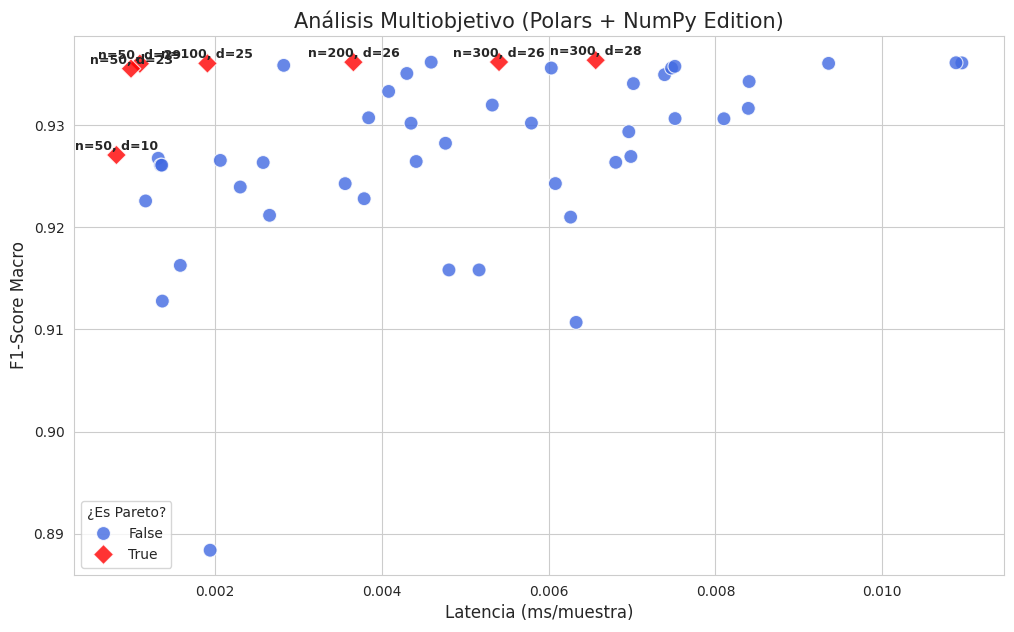

In [8]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargamos los resultados
df = pl.read_csv("rf_trials_results_cv.csv")

# 2. Configuramos el estilo
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 3. Graficamos extrayendo columnas directamente como NumPy
# Al no usar 'data=df', Seaborn acepta arrays de NumPy sin quejarse
sns.scatterplot(
    x=df["latency_ms"].to_numpy(), 
    y=df["f1_macro"].to_numpy(), 
    hue=df["is_pareto"].to_numpy(), # Aquí pasamos la serie de booleanos
    palette={True: "red", False: "royalblue"},
    style=df["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8
)

# 4. Anotaciones de los puntos Pareto (esto ya lo hacíamos con Polars)
pareto_points = df.filter(pl.col("is_pareto") == True)

for row in pareto_points.iter_rows(named=True):
    plt.text(
        row["latency_ms"], 
        row["f1_macro"] + 0.0005, 
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        fontsize=9, fontweight='bold', ha='center'
    )

# 5. Estética
plt.title("Análisis Multiobjetivo (Polars + NumPy Edition)", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.legend(title="¿Es Pareto?")

plt.show()

Se observa que configuraciones con un número reducido de árboles (n=50) y elevada profundidad (max_depth≈29) alcanzan valores de F1-macro prácticamente equivalentes a los modelos de mayor tamaño, pero con una latencia aproximadamente seis veces inferior. Este resultado evidencia que el incremento del número de árboles produce rendimientos decrecientes en términos de eficacia, mientras que el coste computacional continúa aumentando de forma significativa.

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import polars as pl

# 1. Cargamos los resultados pre-calculados
df_res = pl.read_csv("rf_trials_results_cv.csv")

# 2. Definimos la función que actualiza la vista
def ver_configuracion(n_estimators, max_depth):
    clear_output(wait=True) # Limpia la pantalla para que no se amontone
    
    # Buscamos el trial exacto o el más cercano en Polars
    # Filtramos por los valores de los sliders
    match = df_res.filter(
        (pl.col("n_estimators") == n_estimators) & 
        (pl.col("max_depth") == max_depth)
    )
    
    print(f"=== EXPLORADOR DE MODELOS IDS ===")
    print(f"Configuración seleccionada: {n_estimators} árboles, {max_depth} profundidad")
    print("-" * 40)
    
    if len(match) > 0:
        row = match.row(0, named=True)
        # Formateamos la salida con iconos para que quede profesional
        print(f"🎯 F1-Score Macro:   {row['f1_macro']:.5f}")
        print(f"📉 Desviación (Std): {row['f1_std']:.6f}")
        print(f"⚡ Latencia:         {row['latency_ms']:.6f} ms/muestra")
        
        if row['is_pareto']:
            print("\n⭐ ¡ESTA ES UNA CONFIGURACIÓN ÓPTIMA (PARETO)! ⭐")
            print("Recomendada para implementación en el TFG.")
        else:
            print("\n⚠️ Esta configuración es subóptima.")
            print("Hay modelos más rápidos o más precisos disponibles.")
    else:
        print("\n❌ No hay datos para esta combinación exacta.")
        print("Mueve los sliders a valores que Optuna haya probado (ej. n de 50 en 50).")

# 3. Creamos los Sliders (ajustados a los rangos de tu fase 1)
n_slider = widgets.IntSlider(
    value=50, min=50, max=600, step=50, 
    description='n_estimators:', continuous_update=False
)
d_slider = widgets.IntSlider(
    value=10, min=2, max=30, step=1, 
    description='max_depth:', continuous_update=False
)

# 4. Mostramos el Dashboard
ui = widgets.HBox([n_slider, d_slider])
out = widgets.interactive_output(ver_configuracion, {'n_estimators': n_slider, 'max_depth': d_slider})

display(ui, out)

Output()

Vamos a ver como reaccionan en test los modelos con los siguientes hiperparámetros elegidos:

1. (50, 29) Con solo 50 árboles alcanza un F1 casi idéntico al de modelos mucho más pesados
2. (100, 25) Es un punto intermedio, duplica los áeboles respecto al anterior, pero gana robustez
3. (300, 28) Es más lento que los 3, pero es el que más F1 tiene



In [12]:
# Definimos tus 3 configuraciones finalistas
candidatos = [
    {"n": 50,  "d": 29, "nombre": "Alta Eficiencia"},
    {"n": 100, "d": 25, "nombre": "Equilibrado"},
    {"n": 300, "d": 28, "nombre": "Máxima Precisión"}
]

resultados_finales = []

print("--- EVALUACIÓN FINAL SOBRE EL SET DE TEST ---\n")

for c in candidatos:
    print(f"Probando: {c['nombre']} (n={c['n']}, d={c['d']})...")
    
    # 1. Crear y Entrenar (usamos X_full_train que es la suma de train + val)
    model = RandomForestClassifier(
        n_estimators=c['n'],
        max_depth=c['d'],
        n_jobs=-1,
        random_state=42,
        class_weight="balanced_subsample"
    )
    model.fit(X_full_train, y_full_train)
    
    # 2. Medir Inferencia en TEST
    t0 = time.perf_counter()
    y_pred = model.predict(X_test_np)
    t1 = time.perf_counter()
    
    # 3. Calcular métricas
    tiempo_total = t1 - t0
    latencia = (tiempo_total / len(y_test_np)) * 1000
    f1_test = f1_score(y_test_np, y_pred, average='macro')
    acc_test = accuracy_score(y_test_np, y_pred)
    
    resultados_finales.append({
        "Perfil": c['nombre'],
        "n_estimators": c['n'],
        "max_depth": c['d'],
        "F1_Test": f1_test,
        "Accuracy_Test": acc_test,
        "Latencia_ms": latencia
    })

# Convertimos a Polars para mostrar la tabla final
df_final = pl.DataFrame(resultados_finales)
print("\n" + "="*60)
print("              TABLA COMPARATIVA FINAL")
print("="*60)
print(df_final)

--- EVALUACIÓN FINAL SOBRE EL SET DE TEST ---

Probando: Alta Eficiencia (n=50, d=29)...
Probando: Equilibrado (n=100, d=25)...
Probando: Máxima Precisión (n=300, d=28)...

              TABLA COMPARATIVA FINAL
shape: (3, 6)
┌──────────────────┬──────────────┬───────────┬──────────┬───────────────┬─────────────┐
│ Perfil           ┆ n_estimators ┆ max_depth ┆ F1_Test  ┆ Accuracy_Test ┆ Latencia_ms │
│ ---              ┆ ---          ┆ ---       ┆ ---      ┆ ---           ┆ ---         │
│ str              ┆ i64          ┆ i64       ┆ f64      ┆ f64           ┆ f64         │
╞══════════════════╪══════════════╪═══════════╪══════════╪═══════════════╪═════════════╡
│ Alta Eficiencia  ┆ 50           ┆ 29        ┆ 0.873085 ┆ 0.877411      ┆ 0.001193    │
│ Equilibrado      ┆ 100          ┆ 25        ┆ 0.880883 ┆ 0.884504      ┆ 0.001767    │
│ Máxima Precisión ┆ 300          ┆ 28        ┆ 0.876611 ┆ 0.880666      ┆ 0.00547     │
└──────────────────┴──────────────┴───────────┴──────────┴─────

Los resultados en el conjunto de test confirman la hipótesis observada durante la optimización multiobjetivo. El modelo con configuración intermedia (n=100, max_depth=25) presenta el mejor equilibrio entre eficacia y eficiencia, superando en rendimiento al modelo de mayor tamaño (n=300) y manteniendo una latencia significativamente inferior. Esto evidencia la existencia de un régimen de rendimientos decrecientes en Random Forest, donde el incremento del número de árboles no garantiza una mejora proporcional en la capacidad predictiva.

In [13]:
# Guardamos el modelo ganador (Equilibrado) para su uso posterior

# 1. Definimos los hiperparámetros ganadores
n_ganador = 100
d_ganador = 25

modelo_final = RandomForestClassifier(
    n_estimators=n_ganador,
    max_depth=d_ganador,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)

modelo_final.fit(X_full_train, y_full_train)

# 3. Guardamos el modelo en un archivo .joblib
nombre_archivo = "modelo_rf.joblib"
joblib.dump(modelo_final, nombre_archivo)

# 4. Medimos el tamaño del archivo (Dato para tu TFG)
tamano_mb = os.path.getsize(nombre_archivo) / (1024 * 1024)
print(f"📦 Modelo guardado como: {nombre_archivo}")
print(f"📊 Tamaño en disco: {tamano_mb:.2f} MB")

📦 Modelo guardado como: modelo_rf.joblib
📊 Tamaño en disco: 70.86 MB
